# Massive Transfusion Prediction in Trauma Patients

**Task:** Binary classification — predict whether a trauma patient requires Massive Transfusion (MT=1).  
**Dataset:** 1,000 patients · 25% MT prevalence · 80/20 stratified split

## Imports

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, cross_val_predict)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              average_precision_score, precision_recall_curve,
                              brier_score_loss, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import warnings; warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


---
## 1. Load Data & Basic Checks

In [57]:
df = pd.read_excel("CRASH2_Final_Dataset.xlsx")
print(f"Shape: {df.shape}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Unique patients: {df['Patient_ID'].nunique()}")
print(f"\nMT distribution:")
print(df['MT'].value_counts())
print(f"MT prevalence: {df['MT'].mean():.1%}")
df.head()

Shape: (1000, 14)
Duplicates: 0
Unique patients: 1000

MT distribution:
MT
0    750
1    250
Name: count, dtype: int64
MT prevalence: 25.0%


,Patient_ID,Age,Sex,Systolic_BP_mmHg,Heart_Rate_BPM,Respiratory_Rate_BPM,GCS_Score,Injury_Type,Units_Transfused,Lactate_mmol_L,Arterial_Base_Excess,Time_to_Hospital_min,Shock_Index,MT
0,PT-0001,66,Male,128,61,21,13.0,Blunt,0,1.6,0.6,111,0.48,0
1,PT-0002,43,Male,163,79,15,12.0,Blunt,1,1.2,0.8,75,0.48,0
2,PT-0003,80,Male,141,70,18,11.0,Blunt,1,4.0,-4.7,52,0.50,0
3,PT-0004,37,Male,100,86,10,NaN,Blunt,2,1.6,-4.0,40,0.86,0
4,PT-0005,72,Female,128,74,18,NaN,Blunt,0,0.8,-1.3,64,0.58,0


In [58]:
# Verify Shock_Index = HR / SBP (check if dataset column is reliable)
computed_si = df['Heart_Rate_BPM'] / df['Systolic_BP_mmHg']
delta = (df['Shock_Index'] - computed_si).abs()
print(f"Max delta between stored Shock_Index and HR/SBP: {delta.max():.4f}")
print("Shock_Index column is reliable." if delta.max() < 0.01 else "WARNING: Shock_Index mismatch — recalculate!")

Max delta between stored Shock_Index and HR/SBP: 0.0050
Shock_Index column is reliable.


In [59]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDescriptive stats:")
df.describe().round(2)

Missing values:
GCS_Score    379
dtype: int64

Descriptive stats:


,Age,Systolic_BP_mmHg,Heart_Rate_BPM,Respiratory_Rate_BPM,GCS_Score,Units_Transfused,Lactate_mmol_L,Arterial_Base_Excess,Time_to_Hospital_min,Shock_Index,MT
count,1000.00,1000.00,1000.00,1000.00,621.00,1000.00,1000.0,1000.00,1000.00,1000.00,1000.00
mean,51.77,125.23,92.20,16.65,11.65,2.25,3.1,-3.73,61.71,0.80,0.25
std,19.47,26.29,22.74,3.92,2.67,3.31,2.0,3.69,32.98,0.36,0.43
min,18.00,58.00,46.00,10.00,3.00,0.00,0.6,-20.00,5.00,0.24,0.00
25%,35.00,107.00,74.00,14.00,10.00,0.00,1.6,-5.60,34.75,0.53,0.00
50%,51.50,125.00,91.00,16.00,12.00,1.00,2.6,-3.00,62.00,0.74,0.00
75%,69.00,144.00,108.00,19.00,14.00,3.25,4.1,-1.10,90.00,0.98,0.25
max,84.00,202.00,160.00,32.00,15.00,19.00,12.1,2.50,119.00,2.47,1.00


---
## 2. Pre-Split Feature Engineering

Steps done **before** the split:
- Categorical encoding — deterministic (no statistics learned from data).
- Drop columns: `Patient_ID` (ID only), `Units_Transfused` (defines the label — data leakage),  
  `GCS_Score` (37.9% missing — imputing values this sparse is not clinically rational).

Everything else — scaling — happens **inside Pipelines after the split**.

In [60]:
# Encode categoricals (deterministic — no statistics)
df['Injury_Type_Coded'] = df['Injury_Type'].map({'Penetrating': 1, 'Blunt': 0})
df['Sex_Coded']         = df['Sex'].map({'Female': 1, 'Male': 0})

# Drop: ID, leakage column, GCS_Score (too many nulls), Time_to_Hospital_min (not clinically relevant)
df.drop(columns=['Patient_ID', 'Units_Transfused', 'GCS_Score',
                 'Time_to_Hospital_min', 'Injury_Type', 'Sex'], inplace=True)

print("Remaining columns:", df.columns.tolist())
print("Missing values:", df.isnull().sum().sum())

Remaining columns: ['Age', 'Systolic_BP_mmHg', 'Heart_Rate_BPM', 'Respiratory_Rate_BPM', 'Lactate_mmol_L', 'Arterial_Base_Excess', 'Shock_Index', 'MT', 'Injury_Type_Coded', 'Sex_Coded']
Missing values: 0


### Outlier Handling — Clinical Hard Clipping


In [61]:
before = df.shape[0]
# No GCS_Score to filter — it was dropped
# Clip remaining vitals to physiologically survivable bounds
df['Systolic_BP_mmHg'] = df['Systolic_BP_mmHg'].clip(40, 250)
df['Heart_Rate_BPM']   = df['Heart_Rate_BPM'].clip(20, 220)
df['Shock_Index'] = (
    df['Heart_Rate_BPM'] / df['Systolic_BP_mmHg']
)
print(f"Shape: {df.shape} | Missing values: {df.isnull().sum().sum()}")

Shape: (1000, 10) | Missing values: 0


---
## 3. Train / Test Split

Split is done **before** any imputation or scaling.  
`stratify=y` ensures the 25% MT rate is preserved in both sets.

In [62]:
TARGET = 'MT'
y = df[TARGET]
X = df.drop(columns=[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | MT rate: {y_train.mean():.1%}")
print(f"Test : {X_test.shape}  | MT rate: {y_test.mean():.1%}")

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Train: (800, 9) | MT rate: 25.0%
Test : (200, 9)  | MT rate: 25.0%


---
## 4. Feature Sets — Handling Multicollinearity

`Shock_Index = HR / SBP`. Using all three together in Logistic Regression  
causes unstable coefficients (multicollinearity). Two clean sets:

| Set | Features | Excludes |
|---|---|---|
| **Set A** | SBP + HR (raw vitals) | Shock_Index |
| **Set B** | Shock_Index (derived) | SBP + HR |

Tree models (RF, XGBoost) handle collinearity better so they use all features.

In [63]:
# Shared features (no collinearity risk, no GCS_Score, no Time_to_Hospital_min)
SHARED = ['Age', 'Respiratory_Rate_BPM',
          'Lactate_mmol_L', 'Arterial_Base_Excess',
          'Injury_Type_Coded', 'Sex_Coded']

FEAT_A   = ['Systolic_BP_mmHg', 'Heart_Rate_BPM'] + SHARED   # no Shock_Index
FEAT_B   = ['Shock_Index'] + SHARED                           # no SBP/HR
FEAT_ALL = FEAT_A + ['Shock_Index']                           # trees: all features

print("Set A:", FEAT_A)
print("\nSet B:", FEAT_B)
print("\nAll (trees):", FEAT_ALL)

Set A: ['Systolic_BP_mmHg', 'Heart_Rate_BPM', 'Age', 'Respiratory_Rate_BPM', 'Lactate_mmol_L', 'Arterial_Base_Excess', 'Injury_Type_Coded', 'Sex_Coded']

Set B: ['Shock_Index', 'Age', 'Respiratory_Rate_BPM', 'Lactate_mmol_L', 'Arterial_Base_Excess', 'Injury_Type_Coded', 'Sex_Coded']

All (trees): ['Systolic_BP_mmHg', 'Heart_Rate_BPM', 'Age', 'Respiratory_Rate_BPM', 'Lactate_mmol_L', 'Arterial_Base_Excess', 'Injury_Type_Coded', 'Sex_Coded', 'Shock_Index']


---
## 5. Metrics Helper

ROC-AUC alone is insufficient for imbalanced medical data.  
Full metric suite used for every model:

In [64]:
def compute_metrics(y_true, probs, threshold, label=""):
    preds = (probs >= threshold).astype(int)
    cm    = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm.ravel()
    recall   = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec     = tn / (tn + fp) if (tn + fp) > 0 else 0
    prec     = tp / (tp + fp) if (tp + fp) > 0 else 0
    f2       = (5 * prec * recall) / (4 * prec + recall) if (4 * prec + recall) > 0 else 0
    pr_auc   = average_precision_score(y_true, probs)
    roc_auc  = roc_auc_score(y_true, probs)
    brier    = brier_score_loss(y_true, probs)
    return {
        'Model': label, 'CV PR-AUC': '-',
        'PR-AUC': round(pr_auc,3), 'ROC-AUC': round(roc_auc,3),
        'Recall': round(recall,3), 'Specificity': round(spec,3),
        'Precision': round(prec,3), 'F2': round(f2,3),
        'Brier': round(brier,3), 'Threshold': round(threshold,3)
    }, cm


def select_threshold_f2(oof_probs, y_true):
    """Threshold maximising F2 on OOF predictions (training set only)."""
    best_f2, best_t = 0, 0.5
    for t in np.linspace(0.05, 0.95, 500):
        preds = (oof_probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        prec = tp/(tp+fp) if (tp+fp)>0 else 0
        rec  = tp/(tp+fn) if (tp+fn)>0 else 0
        f2   = (5*prec*rec)/(4*prec+rec) if (4*prec+rec)>0 else 0
        if f2 > best_f2:
            best_f2, best_t = f2, t
    print(f"  [F2]      threshold={best_t:.3f}  OOF F2={best_f2:.3f}")
    return best_t


def select_threshold_spec(oof_probs, y_true, min_spec=0.75):
    """Max-Recall threshold while keeping Specificity >= min_spec (OOF only)."""
    best_rec, best_t = 0, None
    for t in np.linspace(0.05, 0.95, 500):
        preds = (oof_probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        spec = tn/(tn+fp) if (tn+fp)>0 else 0
        rec  = tp/(tp+fn) if (tp+fn)>0 else 0
        if spec >= min_spec and rec > best_rec:
            best_rec, best_t = rec, t
    if best_t is None:
        print(f"  [Spec≥{min_spec}] no threshold achieves this constraint")
    else:
        print(f"  [Spec≥{min_spec}] threshold={best_t:.3f}  OOF Recall={best_rec:.3f}")
    return best_t


def plot_cm(cm, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1,
                xticklabels=['Non-MT','MT'], yticklabels=['Non-MT','MT'], ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout(); plt.show()

print("Helpers defined.")

Helpers defined.


---
## 6. Logistic Regression

- Tuned via `GridSearchCV` (5-fold, PR-AUC scoring)
- `StandardScaler` inside the Pipeline — no leakage across CV folds
- Run on Set A and Set B separately to avoid multicollinearity
- Threshold selected on OOF probabilities (not 0.5, not on test)


=== LR Set-A (SBP+HR) ===
  Best params: {'lr__C': 0.1, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'} | CV PR-AUC: 0.826
  [F2]      threshold=0.229  OOF F2=0.769
  [Spec≥0.75] threshold=0.456  OOF Recall=0.840


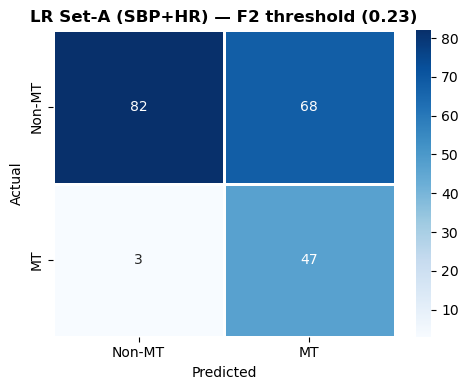


=== LR Set-B (ShockIdx) ===
  Best params: {'lr__C': 10, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'} | CV PR-AUC: 0.799
  [F2]      threshold=0.234  OOF F2=0.765
  [Spec≥0.75] threshold=0.438  OOF Recall=0.780


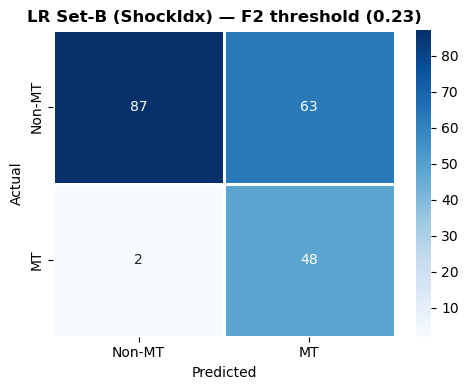

In [65]:
LR_PARAMS = {
    'lr__C':       [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver':  ['liblinear'],
}

def make_lr_pipeline():
    return Pipeline([
        ('imp',    SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('lr',     LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
    ])

results      = []   # primary table (F2 threshold)
results_spec = []   # secondary table (Spec≥0.75 threshold)
stored_probs = {}   # {label: (probs, feat_set)} — reused by plots, no re-fitting

for feat_set, label in [(FEAT_A, 'LR Set-A (SBP+HR)'), (FEAT_B, 'LR Set-B (ShockIdx)')]:
    print(f"\n=== {label} ===")
    gs = GridSearchCV(make_lr_pipeline(), LR_PARAMS, cv=SKF,
                      scoring='average_precision', n_jobs=-1)
    gs.fit(X_train[feat_set], y_train)
    cv_prauc = round(gs.best_score_, 3)
    print(f"  Best params: {gs.best_params_} | CV PR-AUC: {cv_prauc}")

    oof     = cross_val_predict(gs.best_estimator_, X_train[feat_set],
                                 y_train, cv=SKF, method='predict_proba')[:, 1]
    thr_f2  = select_threshold_f2(oof, y_train)
    thr_sp  = select_threshold_spec(oof, y_train)

    gs.best_estimator_.fit(X_train[feat_set], y_train)
    test_probs = gs.best_estimator_.predict_proba(X_test[feat_set])[:, 1]
    stored_probs[label] = (test_probs, feat_set)   # save — no re-fitting needed later

    m, cm = compute_metrics(y_test, test_probs, thr_f2, label)
    m['CV PR-AUC'] = cv_prauc
    results.append(m)
    plot_cm(cm, f"{label} — F2 threshold ({thr_f2:.2f})")

    if thr_sp is not None:
        m2, _ = compute_metrics(y_test, test_probs, thr_sp, label)
        m2['CV PR-AUC'] = cv_prauc
        results_spec.append(m2)

---
## 7. Naive Bayes — Excluded Method (Kept Separate)

Naive Bayes is kept outside the main comparison because its conditional
independence assumption is unlikely to hold for physiological variables,
for example Shock Index, Lactate, and Arterial Base Excess.

  [F2]      threshold=0.050  OOF F2=0.750


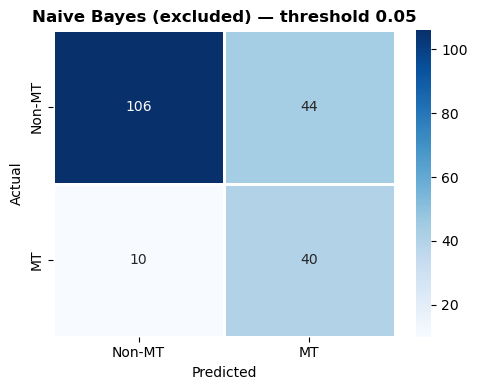


Naive Bayes full metrics:
  Model: Naive Bayes (excl.)
  CV PR-AUC: -
  PR-AUC: 0.738
  ROC-AUC: 0.862
  Recall: 0.8
  Specificity: 0.707
  Precision: 0.476
  F2: 0.704
  Brier: 0.141
  Threshold: 0.05


In [66]:
nb_pipe = Pipeline([
    ('imp',    SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('nb',     GaussianNB())
])

# OOF for threshold selection (same procedure as main models)
oof_nb = cross_val_predict(nb_pipe, X_train[FEAT_B], y_train,
                            cv=SKF, method='predict_proba')[:, 1]
thr_nb = select_threshold_f2(oof_nb, y_train)

nb_pipe.fit(X_train[FEAT_B], y_train)
nb_probs = nb_pipe.predict_proba(X_test[FEAT_B])[:, 1]
stored_probs['Naive Bayes (excl.)'] = (nb_probs, FEAT_B)

nb_metrics, nb_cm = compute_metrics(y_test, nb_probs, thr_nb, 'Naive Bayes (excl.)')
plot_cm(nb_cm, f"Naive Bayes (excluded) — threshold {thr_nb:.2f}")
print("\nNaive Bayes full metrics:")
for k, v in nb_metrics.items():
    print(f"  {k}: {v}")

---
## 8. Random Forest

- No StandardScaler (trees don't need it)
- GridSearchCV on 3 hyperparameters: `n_estimators`, `max_depth`, `class_weight`
- OOF threshold selection (F2 + Spec≥0.75)

=== Random Forest ===
  Best params: {'rf__class_weight': 'balanced_subsample', 'rf__max_depth': 15, 'rf__n_estimators': 200} | CV PR-AUC: 0.8
  [F2]      threshold=0.140  OOF F2=0.763
  [Spec≥0.75] threshold=0.205  OOF Recall=0.810


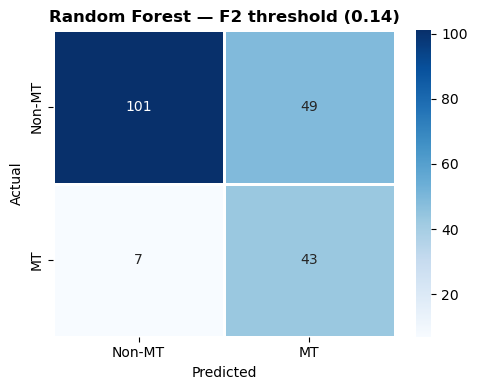

In [67]:
RF_PARAMS = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth':    [5, 10, 15],
    'rf__class_weight': ['balanced', 'balanced_subsample'],
}

rf_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('rf',  RandomForestClassifier(random_state=42, n_jobs=-1))
])

print("=== Random Forest ===")
gs_rf = GridSearchCV(rf_pipe, RF_PARAMS, cv=SKF,
                     scoring='average_precision', n_jobs=-1)
gs_rf.fit(X_train[FEAT_ALL], y_train)
cv_prauc_rf = round(gs_rf.best_score_, 3)
print(f"  Best params: {gs_rf.best_params_} | CV PR-AUC: {cv_prauc_rf}")

oof_rf  = cross_val_predict(gs_rf.best_estimator_, X_train[FEAT_ALL],
                              y_train, cv=SKF, method='predict_proba')[:, 1]
thr_rf  = select_threshold_f2(oof_rf, y_train)
thr_rf_sp = select_threshold_spec(oof_rf, y_train)

gs_rf.best_estimator_.fit(X_train[FEAT_ALL], y_train)
probs_rf = gs_rf.best_estimator_.predict_proba(X_test[FEAT_ALL])[:, 1]
stored_probs['Random Forest'] = (probs_rf, FEAT_ALL)

m_rf, cm_rf = compute_metrics(y_test, probs_rf, thr_rf, 'Random Forest')
m_rf['CV PR-AUC'] = cv_prauc_rf
results.append(m_rf)
plot_cm(cm_rf, f"Random Forest — F2 threshold ({thr_rf:.2f})")

if thr_rf_sp is not None:
    m_rf2, _ = compute_metrics(y_test, probs_rf, thr_rf_sp, 'Random Forest')
    m_rf2['CV PR-AUC'] = cv_prauc_rf
    results_spec.append(m_rf2)

---
## 9. XGBoost — With GridSearch

Tuned with the same procedure as Random Forest for a fair comparison.

=== XGBoost ===
  Best params: {'xgb__learning_rate': 0.2, 'xgb__max_depth': 3, 'xgb__n_estimators': 50, 'xgb__scale_pos_weight': 3.0} | CV PR-AUC: 0.818
  [F2]      threshold=0.187  OOF F2=0.786
  [Spec≥0.75] threshold=0.303  OOF Recall=0.855


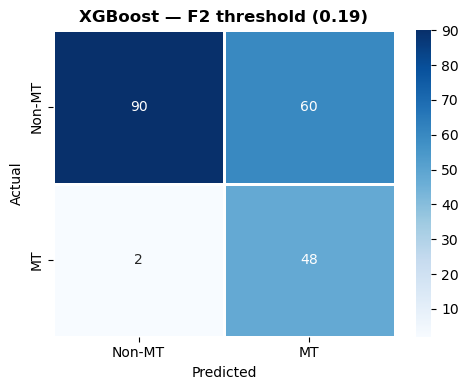

In [68]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
BASE_SPW  = float(neg / pos)

XGB_PARAMS = {
    'xgb__n_estimators':     [50, 100, 200],
    'xgb__max_depth':        [3, 5, 7],
    'xgb__learning_rate':    [0.05, 0.1, 0.2],
    'xgb__scale_pos_weight': [round(BASE_SPW * f, 2) for f in [0.75, 1.0, 1.5]],
}

xgb_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0, n_jobs=-1))
])

print("=== XGBoost ===")
gs_xgb = GridSearchCV(xgb_pipe, XGB_PARAMS, cv=SKF,
                      scoring='average_precision', n_jobs=-1)
gs_xgb.fit(X_train[FEAT_ALL], y_train)
cv_prauc_xgb = round(gs_xgb.best_score_, 3)
print(f"  Best params: {gs_xgb.best_params_} | CV PR-AUC: {cv_prauc_xgb}")

oof_xgb   = cross_val_predict(gs_xgb.best_estimator_, X_train[FEAT_ALL],
                                y_train, cv=SKF, method='predict_proba')[:, 1]
thr_xgb   = select_threshold_f2(oof_xgb, y_train)
thr_xgb_sp = select_threshold_spec(oof_xgb, y_train)

gs_xgb.best_estimator_.fit(X_train[FEAT_ALL], y_train)
probs_xgb = gs_xgb.best_estimator_.predict_proba(X_test[FEAT_ALL])[:, 1]
stored_probs['XGBoost'] = (probs_xgb, FEAT_ALL)

m_xgb, cm_xgb = compute_metrics(y_test, probs_xgb, thr_xgb, 'XGBoost')
m_xgb['CV PR-AUC'] = cv_prauc_xgb
results.append(m_xgb)
plot_cm(cm_xgb, f"XGBoost — F2 threshold ({thr_xgb:.2f})")

if thr_xgb_sp is not None:
    m_xgb2, _ = compute_metrics(y_test, probs_xgb, thr_xgb_sp, 'XGBoost')
    m_xgb2['CV PR-AUC'] = cv_prauc_xgb
    results_spec.append(m_xgb2)

---
## 10. Full Model Comparison Table

**Model selection is based on CV PR-AUC (training set only) — not on test results.**  
Test metrics are reported for reference but were not used to select the winner.  
Two tables: primary (F2-maximising threshold) and secondary (Spec≥0.75 threshold).

In [69]:
col_order = ['CV PR-AUC','PR-AUC','ROC-AUC','Recall','Specificity',
             'Precision','F2','Brier','Threshold']

# Primary table — F2-optimised threshold
df_results = pd.DataFrame(results).set_index('Model')[col_order]
print("PRIMARY TABLE — F2-optimised threshold")
display(df_results)

# Secondary table — Spec≥0.75 threshold
if results_spec:
    df_spec = pd.DataFrame(results_spec).set_index('Model')[col_order]
    print("\nSECONDARY TABLE — Max Recall at Specificity ≥ 0.75")
    display(df_spec)

PRIMARY TABLE — F2-optimised threshold


,CV PR-AUC,PR-AUC,ROC-AUC,Recall,Specificity,Precision,F2,Brier,Threshold
Model,,,,,,,,,
LR Set-A (SBP+HR),0.826,0.766,0.882,0.94,0.547,0.409,0.746,0.139,0.229
LR Set-B (ShockIdx),0.799,0.757,0.882,0.96,0.580,0.432,0.772,0.136,0.234
Random Forest,0.800,0.756,0.880,0.86,0.673,0.467,0.736,0.113,0.140
XGBoost,0.818,0.784,0.903,0.96,0.600,0.444,0.779,0.114,0.187



SECONDARY TABLE — Max Recall at Specificity ≥ 0.75


,CV PR-AUC,PR-AUC,ROC-AUC,Recall,Specificity,Precision,F2,Brier,Threshold
Model,,,,,,,,,
LR Set-A (SBP+HR),0.826,0.766,0.882,0.82,0.787,0.562,0.751,0.139,0.456
LR Set-B (ShockIdx),0.799,0.757,0.882,0.78,0.780,0.542,0.717,0.136,0.438
Random Forest,0.800,0.756,0.880,0.84,0.760,0.538,0.755,0.113,0.205
XGBoost,0.818,0.784,0.903,0.88,0.727,0.518,0.772,0.114,0.303


## 11. ROC & Precision-Recall Curves

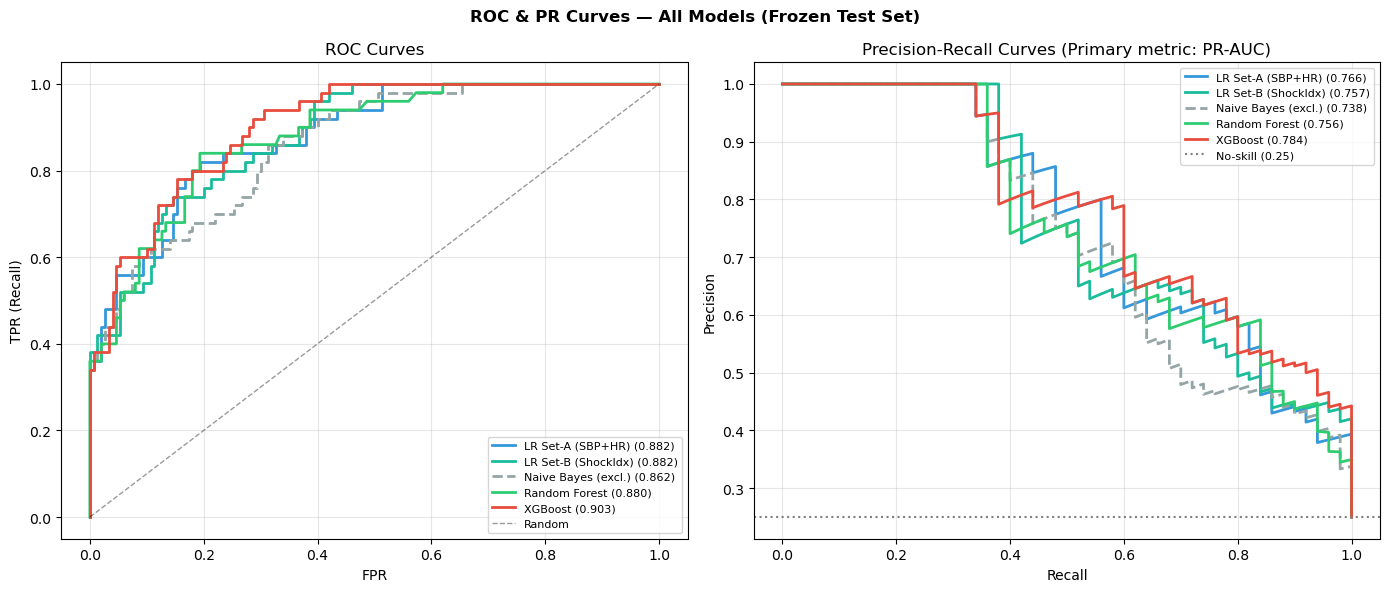

In [70]:
# Use stored_probs — no re-fitting needed
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))
prevalence = y_test.mean()

palette = {
    'LR Set-A (SBP+HR)':    ('#3498db', '-'),
    'LR Set-B (ShockIdx)':  ('#1abc9c', '-'),
    'Random Forest':         ('#2ecc71', '-'),
    'XGBoost':               ('#e74c3c', '-'),
    'Naive Bayes (excl.)':  ('#95a5a6', '--'),
}

for name, (probs, _) in stored_probs.items():
    color, ls = palette.get(name, ('#888888', ':'))
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax_roc.plot(fpr, tpr, color=color, ls=ls, lw=2, label=f"{name} ({auc:.3f})")

    prec_c, rec_c, _ = precision_recall_curve(y_test, probs)
    prauc = average_precision_score(y_test, probs)
    ax_pr.plot(rec_c, prec_c, color=color, ls=ls, lw=2, label=f"{name} ({prauc:.3f})")

ax_roc.plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='Random')
ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR (Recall)")
ax_roc.set_title("ROC Curves"); ax_roc.legend(fontsize=8); ax_roc.grid(alpha=0.3)

ax_pr.axhline(prevalence, color='grey', ls=':', lw=1.5, label=f"No-skill ({prevalence:.2f})")
ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall Curves (Primary metric: PR-AUC)")
ax_pr.legend(fontsize=8); ax_pr.grid(alpha=0.3)

plt.suptitle("ROC & PR Curves — All Models (Frozen Test Set)", fontweight='bold')
plt.tight_layout(); plt.show()

## 12. Calibration

 "predicted probability of 0.7" actually corresponds  
to ~70% of those patients having MT. Brier score = mean squared error of probabilities.

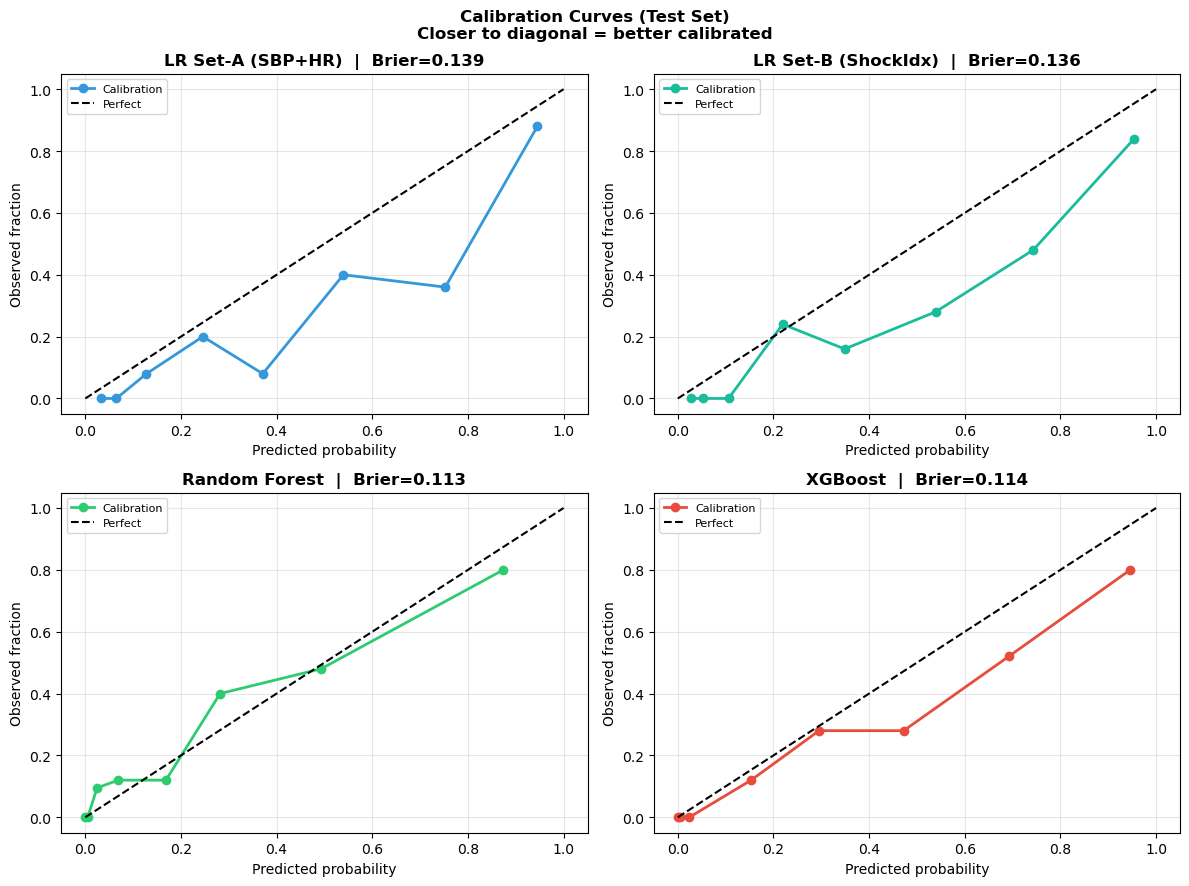

In [71]:
main_models = [(n, p) for n, (p, _) in stored_probs.items()
               if 'excl' not in n.lower()]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
colors = ['#3498db','#1abc9c','#2ecc71','#e74c3c']

for i, (name, probs) in enumerate(main_models[:4]):
    brier = brier_score_loss(y_test, probs)
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=8, strategy='quantile')
    ax = axes[i]
    ax.plot(prob_pred, prob_true, 'o-', color=colors[i], lw=2, label='Calibration')
    ax.plot([0,1],[0,1],'k--', lw=1.5, label='Perfect')
    ax.set_title(f"{name}  |  Brier={brier:.3f}", fontweight='bold')
    ax.set_xlabel("Predicted probability"); ax.set_ylabel("Observed fraction")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Calibration Curves (Test Set)\nCloser to diagonal = better calibrated",
             fontweight='bold')
plt.tight_layout(); plt.show()

## 13. Permutation Importance — Random Forest (Explanation Only)

Shows which features the **Random Forest model** relies on most.  
**Used for interpretation only — not for feature removal decisions.**  

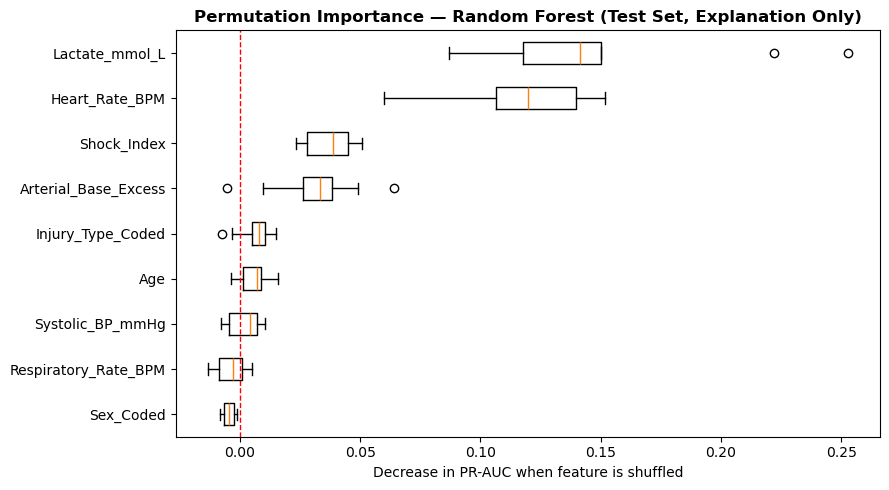

In [72]:
perm = permutation_importance(gs_rf.best_estimator_, X_test[FEAT_ALL], y_test,
                               n_repeats=10, random_state=42, n_jobs=-1,
                               scoring='average_precision')
sorted_idx = perm.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(perm.importances[sorted_idx].T, vert=False,
           labels=[FEAT_ALL[i] for i in sorted_idx])
ax.axvline(0, color='red', lw=1, ls='--')
ax.set_xlabel("Decrease in PR-AUC when feature is shuffled")
ax.set_title("Permutation Importance — Random Forest (Test Set, Explanation Only)",
             fontweight='bold')
plt.tight_layout(); plt.show()

## 14. Conclusions

*Conclusions are drawn from the actual table above*

In [73]:
# Winner selected by CV PR-AUC (training set) — NOT by test results
ml_models = df_results.copy()
winner = ml_models['CV PR-AUC'].astype(float).idxmax()

print("=" * 65)
print(f"Pre-selected winner by CV PR-AUC (training set): {winner}")
print(f"CV PR-AUC: {ml_models.loc[winner, 'CV PR-AUC']}")
print()

# Report test performance of the pre-selected winner
print(f"Test performance of pre-selected model ({winner}):")
for col in ['PR-AUC','ROC-AUC','Recall','Specificity','Precision','F2','Brier']:
    print(f"  {col:<15}: {ml_models.loc[winner, col]}")

print()
# Naive Bayes comparison — neutral wording
nb_prauc = nb_metrics['PR-AUC']
min_main  = ml_models['PR-AUC'].astype(float).min()
print(f"Naive Bayes (excluded) PR-AUC: {nb_prauc}")
print(f"Lowest main-model PR-AUC:      {min_main}")
if nb_prauc < min_main:
    print("→ Naive Bayes performed worse than all main models on this split.")
else:
    print("→ Naive Bayes performed comparably on this split — review assumption.")

print()
# LR Set-A vs Set-B
lr_rows = [r for r in ml_models.index if 'LR' in r]
print("LR Set-A vs Set-B:")
for r in lr_rows:
    print(f"  {r}: PR-AUC={ml_models.loc[r,'PR-AUC']}  "
          f"Recall={ml_models.loc[r,'Recall']}  Spec={ml_models.loc[r,'Specificity']}")
print("=" * 65)

Pre-selected winner by CV PR-AUC (training set): LR Set-A (SBP+HR)
CV PR-AUC: 0.826

Test performance of pre-selected model (LR Set-A (SBP+HR)):
  PR-AUC         : 0.766
  ROC-AUC        : 0.882
  Recall         : 0.94
  Specificity    : 0.547
  Precision      : 0.409
  F2             : 0.746
  Brier          : 0.139

Naive Bayes (excluded) PR-AUC: 0.738
Lowest main-model PR-AUC:      0.756
→ Naive Bayes performed worse than all main models on this split.

LR Set-A vs Set-B:
  LR Set-A (SBP+HR): PR-AUC=0.766  Recall=0.94  Spec=0.547
  LR Set-B (ShockIdx): PR-AUC=0.757  Recall=0.96  Spec=0.58
